#Clone FaceForensics Repository

In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub

In [ ]:
import kagglehub
path = kagglehub.dataset_download("ciplab/real-and-fake-face-detection")
print("Path to dataset files:", path)

100%|██████████| 431M/431M [00:11<00:00, 39.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ciplab/real-and-fake-face-detection/versions/1


In [ ]:
import os
os.listdir(path)

['real_and_fake_face_detection', 'real_and_fake_face']

In [ ]:
real_path = os.path.join(path, "real_and_fake_face", "training_real")
fake_path = os.path.join(path, "real_and_fake_face", "training_fake")

print("Real images:", len(os.listdir(real_path)))
print("Fake images:", len(os.listdir(fake_path)))

Real images: 1081
Fake images: 960


(np.float64(-0.5), np.float64(599.5), np.float64(599.5), np.float64(-0.5))

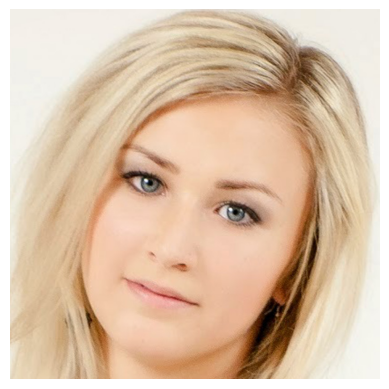

In [ ]:
import cv2 #openCV
import matplotlib.pyplot as plt #vis

img = cv2.imread(real_path + "/" + os.listdir(real_path)[0])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")

## Import necessary libraries



In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

#Extract Frames from Videos

In [ ]:
def extract_frames(video_path, label, frames=10):

    data = []
    labels = []

    cap = cv2.VideoCapture(video_path)
    count = 0

    while cap.isOpened() and count < frames:
        ret, frame = cap.read()

        if not ret:
            break

        frame = cv2.resize(frame,(224,224))
        data.append(frame)
        labels.append(label)

        count += 1

    cap.release()

    return data, labels

#Load Data

In [ ]:
data = []
labels = []

##Load Real Videos.

In [ ]:
for video in os.listdir(real_path)[:50]:

    video_file = os.path.join(real_path, video)

    d,l = extract_frames(video_file,0)

    data.extend(d)
    labels.extend(l)

##Load Fake Videos

In [ ]:
for video in os.listdir(fake_path)[:50]:

    video_file = os.path.join(fake_path, video)

    d,l = extract_frames(video_file,1)

    data.extend(d)
    labels.extend(l)

#Convert to Numpy

In [ ]:
X = np.array(data) / 255.0
y = np.array(labels)

print(X.shape)

(100, 224, 224, 3)


#Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

#Method-1: Build CNN Model

In [ ]:
model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64,activation='relu'),


    tf.keras.layers.Dense(1,activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,177,281 (42.64 MB)

 Trainable params: 11,177,281 (42.64 MB)

 Non-trainable params: 0 (0.00 B)

#Train Model

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test,y_test),
    epochs=20,
    batch_size=32
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.5492 - loss: 0.6941 - val_accuracy: 0.6500 - val_loss: 0.6898
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.5617 - loss: 0.6801 - val_accuracy: 0.4000 - val_loss: 0.7007
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.4422 - loss: 0.7141 - val_accuracy: 0.4000 - val_loss: 0.7176
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - accuracy: 0.5047 - loss: 0.7065 - val_accuracy: 0.4000 - val_loss: 0.7285
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.4953 - loss: 0.7031 - val_accuracy: 0.4000 - val_loss: 0.7247
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.4883 - loss: 0.6817 - val_accuracy: 0.4000 - val_loss: 0.7115
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.5805 - loss: 0.6814 - val_accuracy: 0.4000 - val_loss: 0.7087
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.4641 - loss: 0.6999 - val_accuracy: 0.4000 - val_loss:

#Plot Accuracy

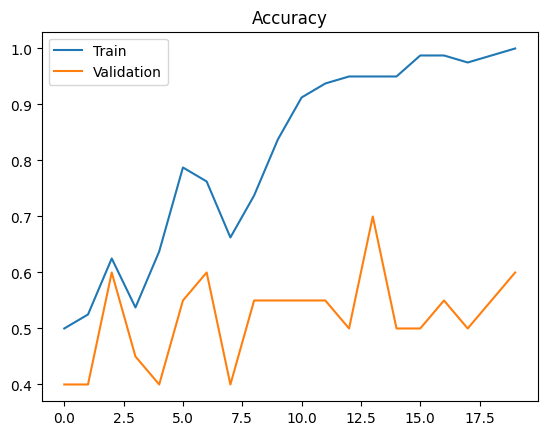

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.title("Accuracy")
plt.show()

#Test Prediction

In [ ]:
def predict_image(img_path):

    img = cv2.imread(img_path)
    img = cv2.resize(img,(224,224))
    img = img/255.0
    img = np.reshape(img,(1,224,224,3))

    pred = model.predict(img)

    if pred > 0.5:
        print("Fake Video Frame")
    else:
        print("Real Video Frame")

In [ ]:
# Test Accuracy
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6000 - loss: 1.8390
Test Loss: 1.838971495628357
Test Accuracy: 0.6000000238418579


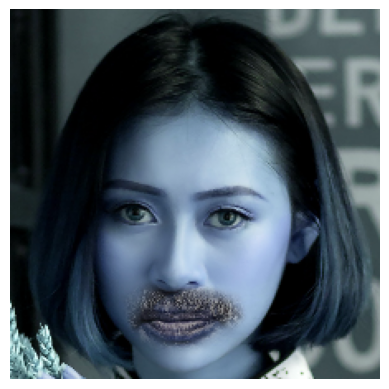

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step
Predicted: REAL
Actual Label: 1


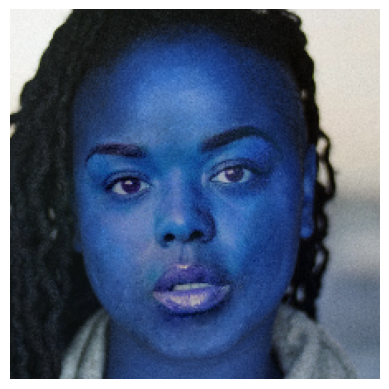

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Predicted: REAL
Actual Label: 1


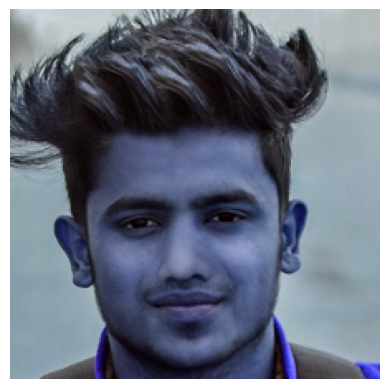

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Predicted: FAKE
Actual Label: 1


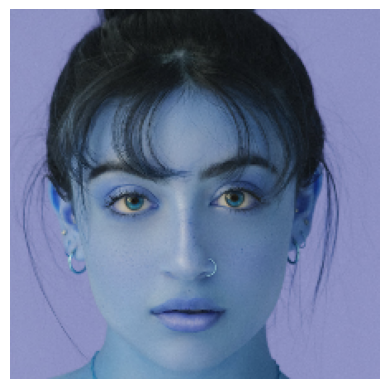

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Predicted: REAL
Actual Label: 0


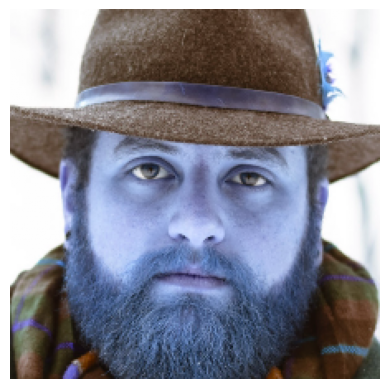

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Predicted: REAL
Actual Label: 0


In [ ]:
import matplotlib.pyplot as plt

for i in range(5):

    img = X_test[i]

    plt.imshow(img)
    plt.axis("off")
    plt.show()

    pred = model.predict(np.expand_dims(img, axis=0))

    if pred[0][0] > 0.5:
        print("Predicted: FAKE")
    else:
        print("Predicted: REAL")

    print("Actual Label:", y_test[i])

In [ ]:
model.save("cnn_model.h5")

# Method-2:Model by using Transfer Learning

In [ ]:
base_model = tf.keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
for layer in base_model.layers:
    layer.trainable = False

##Add Custom Layers

In [ ]:
x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)

output = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.models.Model(inputs=base_model.input, outputs=output)

#Compille Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
history_resnet = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=25,
    batch_size=32
)

Epoch 1/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 27s 6s/step - accuracy: 0.5898 - loss: 0.7678 - val_accuracy: 0.6000 - val_loss: 0.6770
Epoch 2/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.4516 - loss: 0.8897 - val_accuracy: 0.6000 - val_loss: 0.6849
Epoch 3/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.4797 - loss: 0.7903 - val_accuracy: 0.4000 - val_loss: 0.8016
Epoch 4/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.5719 - loss: 0.7691 - val_accuracy: 0.4000 - val_loss: 0.8627
Epoch 5/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.4781 - loss: 0.8482 - val_accuracy: 0.6000 - val_loss: 0.6801
Epoch 6/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.4773 - loss: 0.8042 - val_accuracy: 0.6000 - val_loss: 0.7077
Epoch 7/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.4977 - loss: 0.8833 - val_accuracy: 0.6000 - val_loss: 0.6783
Epoch 8/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.4617 - loss: 0.7562 - val_accuracy: 0.4000 - val_loss: 0

In [ ]:
test_loss_resnet, test_accuracy_resnet = model.evaluate(X_test, y_test)

print("ResNet Test Loss:", test_loss_resnet)
print("ResNet Test Accuracy:", test_accuracy_resnet)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.6000 - loss: 0.6911
ResNet Test Loss: 0.6911189556121826
ResNet Test Accuracy: 0.6000000238418579


##Save model

In [ ]:
model.save("deepfake_model.h5")

In [ ]:
from tensorflow.keras.models import load_model

cnn_model = load_model("cnn_model.h5")
resnet_model = load_model("deepfake_model.h5")

In [ ]:
cnn_loss, cnn_accuracy = cnn_model.evaluate(X_test, y_test)

print("CNN Model Accuracy:", cnn_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.6000 - loss: 0.6911
CNN Model Accuracy: 0.6000000238418579


In [ ]:
resnet_loss, resnet_accuracy = resnet_model.evaluate(X_test, y_test)

print("ResNet Model Accuracy:", resnet_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.6000 - loss: 0.6911
ResNet Model Accuracy: 0.6000000238418579


#Load Model for Real-Time Detection

In [ ]:
from tensorflow.keras.models import load_model
import cv2
import numpy as np

model = load_model("deepfake_model.h5")

# Webcam Capture in Google Colab

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
from PIL import Image
import io

def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
          const div = document.createElement('div');
          const capture = document.createElement('button');
          capture.textContent = 'Capture';
          div.appendChild(capture);

          const video = document.createElement('video');
          video.style.display = 'block';
          const stream = await navigator.mediaDevices.getUserMedia({video: true});

          document.body.appendChild(div);
          div.appendChild(video);
          video.srcObject = stream;
          await video.play();

          google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

          await new Promise((resolve) => capture.onclick = resolve);

          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);
          stream.getVideoTracks()[0].stop();
          div.remove();
          return canvas.toDataURL('image/jpeg', quality);
        }
    ''')

    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

#Capture Image From Camera

In [ ]:
image_path = take_photo()
print("Image captured")

<IPython.core.display.Javascript object>

MessageError: NotAllowedError: Permission denied

#Predict Real vs Fake

In [ ]:
def detect_deepfake(image_path):

    img = cv2.imread(image_path)
    img = cv2.resize(img,(224,224))
    img = img/255.0
    img = np.reshape(img,(1,224,224,3))

    pred = model.predict(img)

    if pred > 0.5:
        print("⚠️ Fake Face Detected")
    else:
        print("✅ Real Face Detected")

#Real-Time Detection Loop (Repeat Capture)

In [ ]:
detect_deepfake(image_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
✅ Real Face Detected
